# Demo pitch + loudness + reconstrucción simple

1. Carga una muestra de NSynth
2. Extrae `f0` y `periodicity` con `torchcrepe`
3. Calcula una envolvente simple de energía (`RMS`)
4. Reconstruye una senoide controlada por `f0` y `RMS`
5. Reproduce el audio original y el reconstruido


PROBLEMAS EN ESTE NOTEBOOK:
primero q es muy simple porq es una senoide pura sin armonicos
despues, los graves no se reconocen y es pq pitch_filt silencia frames con baja periodicity, que es bja en graves, la senoide existe pero la frecuencia es inaudible.
hop_length es inconsistente entre CREPE y RMS, el frame length no coincide bien con el hop d crepe
phase acumula el error d precision con float32 y millones d samples, cumsum acumula drift numerico
el rango d crepe es demasiado estrecho


In [32]:
%run init_notebook.py
import sys
sys.path.append('src')

import math
import torch
import torchaudio
import torchcrepe
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import math
import torch
import torchaudio
import torchcrepe
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from src.dataset import NSynth


In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


device: cuda
gpu: NVIDIA GeForce RTX 3090


In [34]:
#podemos cambiar idx por otra muestra si queremos 
idx = 39
ds = NSynth('training')
waveform, sr, key, metadata = ds[idx]

if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

audio = waveform.to(device)
n_samples = audio.shape[-1]

print('key:', key)
print('sample_rate:', sr)
print('shape:', waveform.shape)
print('metadata:', metadata)

display(Audio(waveform.squeeze().cpu().numpy(), rate=sr))


Carga completada: 289205 muestras de todos los instrumentos.
key: bass_synthetic_042-023-075
sample_rate: 16000
shape: torch.Size([1, 64000])
metadata: {'one_hot_instrument': tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'instrument_family_id': 0, 'instrument_family_str': 'bass'}


extraemos f0 y periodicity

In [35]:
hop_length = int(sr / 200.0)  # ~5 ms

pitch, periodicity = torchcrepe.predict(
    audio,
    sr,
    hop_length,
    32.70,
    1975.53,
    model='tiny',
    return_periodicity=True,
    batch_size=512,
    device=device,
)

pitch = pitch.squeeze(0)
periodicity = periodicity.squeeze(0)

pitch = torch.nan_to_num(pitch, nan=0.0, posinf=0.0, neginf=0.0)
periodicity = torch.nan_to_num(periodicity, nan=0.0, posinf=0.0, neginf=0.0)

# Filtrar frames poco fiables
pitch_filt = torch.where(periodicity > 0.7, pitch, torch.zeros_like(pitch))

valid = pitch_filt[pitch_filt > 0]
if valid.numel() > 0:
    print('pitch medio filtrado (Hz):', valid.mean().item())
    print('pitch mediano filtrado (Hz):', valid.median().item())
else:
    print('no se detectó pitch válido')


no se detectó pitch válido


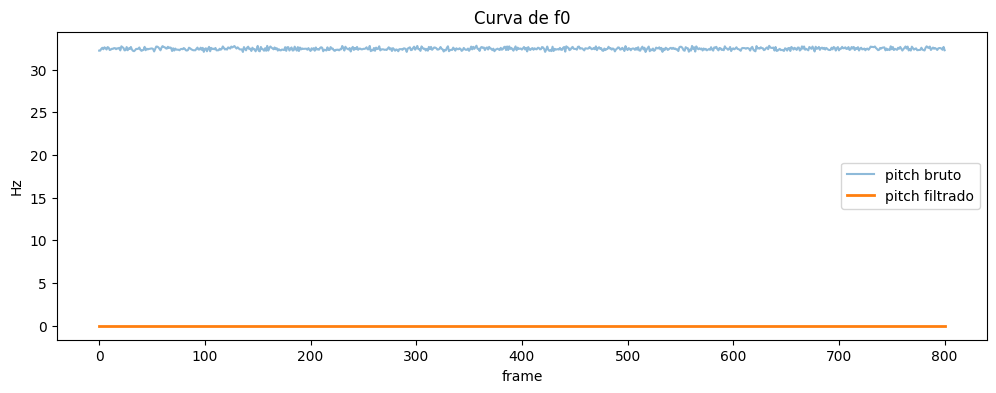

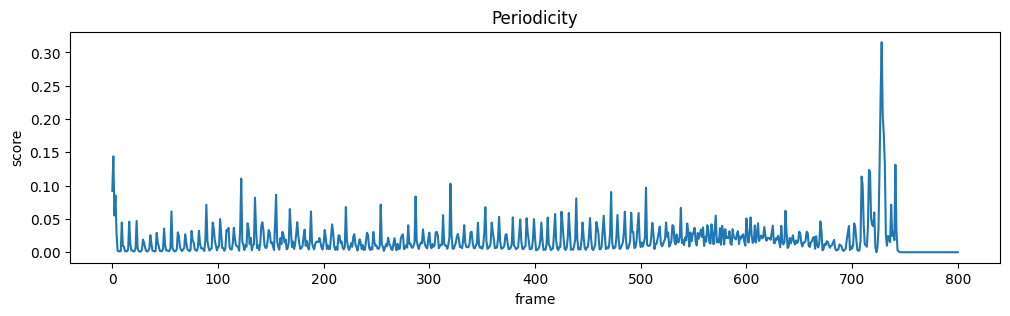

In [36]:
plt.figure(figsize=(12,4))
plt.plot(pitch.cpu().numpy(), label='pitch bruto', alpha=0.5)
plt.plot(pitch_filt.cpu().numpy(), label='pitch filtrado', linewidth=2)
plt.title('Curva de f0')
plt.xlabel('frame')
plt.ylabel('Hz')
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(periodicity.cpu().numpy())
plt.title('Periodicity')
plt.xlabel('frame')
plt.ylabel('score')
plt.show()


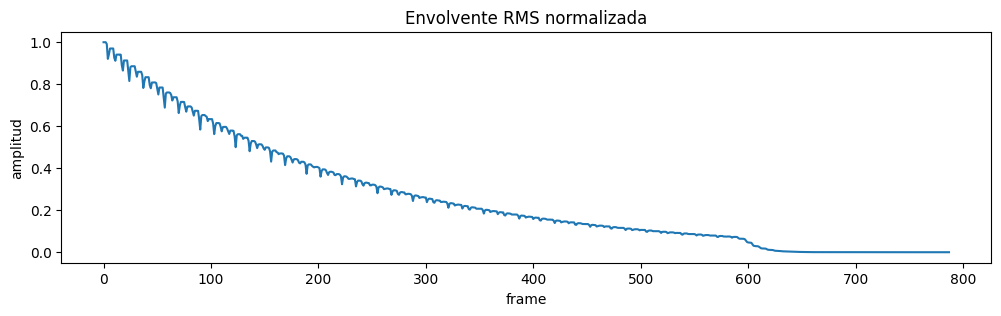

In [37]:
frame_length = 1024
rms = audio.unfold(-1, frame_length, hop_length)
rms = torch.sqrt(torch.mean(rms ** 2, dim=-1) + 1e-8).squeeze(0)
rms = rms / (rms.max() + 1e-8)

plt.figure(figsize=(12,3))
plt.plot(rms.detach().cpu().numpy())
plt.title('Envolvente RMS normalizada')
plt.xlabel('frame')
plt.ylabel('amplitud')
plt.show()


In [38]:
pitch_up = torch.nn.functional.interpolate(
    pitch_filt[None, None, :],
    size=n_samples,
    mode='linear',
    align_corners=False
).squeeze()
pitch_up = torch.clamp(pitch_up, min=1.0)

rms_up = torch.nn.functional.interpolate(
    rms[None, None, :],
    size=n_samples,
    mode='linear',
    align_corners=False
).squeeze()
rms_up = torch.clamp(rms_up, min=0.0, max=1.0)

phase = 2 * math.pi * torch.cumsum(pitch_up / sr, dim=0)
sine = 0.2 * rms_up * torch.sin(phase)

recon = sine.detach().cpu().unsqueeze(0)
torchaudio.save('recon_sine_loudness.wav', recon, sr)
print('guardado: recon_sine_loudness.wav')


guardado: recon_sine_loudness.wav


In [39]:
display(Audio(recon.squeeze().numpy(), rate=sr))


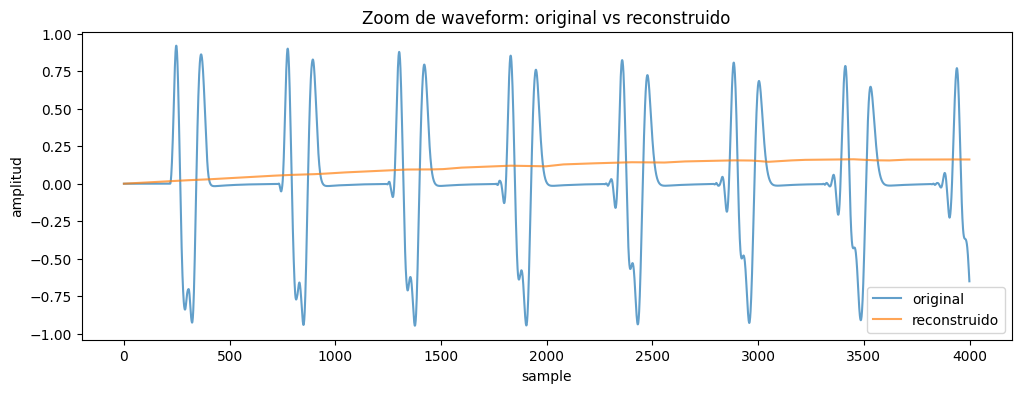

In [40]:
plt.figure(figsize=(12,4))
plt.plot(waveform.squeeze().cpu().numpy()[:4000], label='original', alpha=0.7)
plt.plot(recon.squeeze().numpy()[:4000], label='reconstruido', alpha=0.7)
plt.title('Zoom de waveform: original vs reconstruido')
plt.xlabel('sample')
plt.ylabel('amplitud')
plt.legend()
plt.show()


In [41]:
print('Audio original:')
display(Audio(waveform.squeeze().cpu().numpy(), rate=sr))
print('Audio reconstruido:')
display(Audio(recon.squeeze().numpy(), rate=sr))


Audio original:


Audio reconstruido:
